# 05 · Feature Engineering

**Purpose:** Aggregate per `(ticker, date)` and create the predictive feature table.

**Base features (daily):**
- `news_count` — number of unique articles mentioning the ticker
- `avg_sentiment`, `std_sentiment` — mean and std of sentiment score
- `positive_ratio`, `negative_ratio` — share of positive / negative articles
- `event_ma`, `event_earnings`, `event_management`, `event_legal` — event mention counts
- `negated_count`, `speculative_count` — modifier counts

**Rolling features:** 3-day and 7-day rolling means for all base features.

**Input:** `articles_enriched.parquet`, `events.parquet`  
**Output:** `features.parquet`

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

NB_DIR = Path().resolve()
sys.path.insert(0, str(NB_DIR))
from utils import load, save

In [2]:
enriched = load("articles_enriched")
events   = load("events")

print(f"Enriched rows: {len(enriched):,}")
print(f"Event rows:    {len(events):,}")

Enriched rows: 4,993
Event rows:    4,993


## 1 · Merge sentiment + events

In [3]:
SENTIMENT_NUM = {"positive": 1.0, "neutral": 0.0, "negative": -1.0}

enriched = enriched.copy()
enriched["sentiment_num"] = enriched["sentiment"].map(SENTIMENT_NUM).fillna(0.0)
enriched["is_positive"]   = (enriched["sentiment"] == "positive").astype(int)
enriched["is_negative"]   = (enriched["sentiment"] == "negative").astype(int)

EVENT_BOOL_COLS = ["event_ma", "event_earnings", "event_management", "event_legal",
                   "is_negated", "is_speculative"]

merged = enriched.merge(
    events[["article_url", "ticker"] + EVENT_BOOL_COLS].drop_duplicates(["article_url", "ticker"]),
    on=["article_url", "ticker"],
    how="left",
)
for col in EVENT_BOOL_COLS:
    merged[col] = merged[col].fillna(False).astype(int)

merged["date"] = pd.to_datetime(merged["date"])
print(f"Merged rows: {len(merged):,}")

Merged rows: 4,993


## 2 · Daily aggregation

In [4]:
def aggregate_daily(df: pd.DataFrame) -> pd.DataFrame:
    agg = df.groupby(["ticker", "date"]).agg(
        news_count        =("article_url",   "nunique"),
        avg_sentiment     =("sentiment_num", "mean"),
        std_sentiment     =("sentiment_num", "std"),
        positive_count    =("is_positive",   "sum"),
        negative_count    =("is_negative",   "sum"),
        event_ma          =("event_ma",       "sum"),
        event_earnings    =("event_earnings", "sum"),
        event_management  =("event_management", "sum"),
        event_legal       =("event_legal",    "sum"),
        negated_count     =("is_negated",     "sum"),
        speculative_count =("is_speculative", "sum"),
    ).reset_index()

    agg["std_sentiment"]  = agg["std_sentiment"].fillna(0.0)
    agg["positive_ratio"] = agg["positive_count"] / agg["news_count"]
    agg["negative_ratio"] = agg["negative_count"] / agg["news_count"]
    return agg


daily = aggregate_daily(merged)
print(f"Daily feature rows: {len(daily):,}")
print(f"Tickers covered:    {daily['ticker'].nunique()}")
print(f"Date range:         {daily['date'].min().date()} → {daily['date'].max().date()}")
daily.head()

Daily feature rows: 892
Tickers covered:    60
Date range:         2006-09-20 → 2026-05-21


,ticker,date,news_count,avg_sentiment,std_sentiment,positive_count,negative_count,event_ma,event_earnings,event_management,event_legal,negated_count,speculative_count,positive_ratio,negative_ratio
0,ADH,2006-09-20,1,1.0,0.0,1,0,0,0,1,0,0,0,1.0,0.0
1,ADH,2013-04-24,1,1.0,0.0,1,0,0,0,1,0,1,0,1.0,0.0
2,ADH,2016-07-15,1,1.0,0.0,1,0,0,0,0,0,1,0,1.0,0.0
3,ADH,2019-01-30,1,0.0,0.0,0,0,0,1,0,0,1,0,0.0,0.0
4,ADH,2019-04-16,1,1.0,0.0,1,0,1,1,0,0,0,0,1.0,0.0


## 3 · Rolling features (3d, 7d)

In [5]:
ROLLING_BASE_COLS = [
    "news_count", "avg_sentiment", "std_sentiment",
    "positive_ratio", "negative_ratio",
    "event_ma", "event_earnings", "event_management", "event_legal",
]

WINDOWS = [3, 7]


def add_rolling_features(df: pd.DataFrame, base_cols: list[str], windows: list[int]) -> pd.DataFrame:
    df = df.sort_values(["ticker", "date"]).copy()
    for w in windows:
        for col in base_cols:
            df[f"{col}_r{w}d"] = (
                df.groupby("ticker")[col]
                  .transform(lambda x: x.rolling(w, min_periods=1).mean())
            )
    return df


features = add_rolling_features(daily, ROLLING_BASE_COLS, WINDOWS)

feature_cols = [c for c in features.columns if c not in ["ticker", "date"]]
print(f"Total feature columns: {len(feature_cols)}")
print(", ".join(feature_cols))

Total feature columns: 31
news_count, avg_sentiment, std_sentiment, positive_count, negative_count, event_ma, event_earnings, event_management, event_legal, negated_count, speculative_count, positive_ratio, negative_ratio, news_count_r3d, avg_sentiment_r3d, std_sentiment_r3d, positive_ratio_r3d, negative_ratio_r3d, event_ma_r3d, event_earnings_r3d, event_management_r3d, event_legal_r3d, news_count_r7d, avg_sentiment_r7d, std_sentiment_r7d, positive_ratio_r7d, negative_ratio_r7d, event_ma_r7d, event_earnings_r7d, event_management_r7d, event_legal_r7d


## 4 · LLM event_type features

One-hot encode the LLM-assigned `event_type` per article and aggregate at `(ticker, date)`.
This gives the model a richer, semantically-grounded event signal alongside the rule-based flags.

In [6]:
sentiments_full = load("sentiments")

# Bring event_type into the enriched frame
enriched_et = enriched.merge(
    sentiments_full[["article_url", "event_type"]].dropna(subset=["event_type"]),
    on="article_url",
    how="left",
)
enriched_et["event_type"] = enriched_et["event_type"].fillna("other")

# One-hot encode
et_dummies = pd.get_dummies(enriched_et["event_type"], prefix="llm_evt")
enriched_et = pd.concat([enriched_et, et_dummies], axis=1)

LLM_EVT_COLS = [c for c in enriched_et.columns if c.startswith("llm_evt_")]
print(f"LLM event_type columns ({len(LLM_EVT_COLS)}): {LLM_EVT_COLS}")

# Daily aggregation for LLM event columns
enriched_et["date"] = pd.to_datetime(enriched_et["date"])
daily_llm = (
    enriched_et.groupby(["ticker", "date"])[LLM_EVT_COLS]
    .sum()
    .reset_index()
)

features = features.merge(daily_llm, on=["ticker", "date"], how="left")
for col in LLM_EVT_COLS:
    features[col] = features[col].fillna(0)

print(f"Features shape after LLM event columns: {features.shape}")

LLM event_type columns (11): ['llm_evt_capital_operation', 'llm_evt_debt_issuance', 'llm_evt_earnings_release', 'llm_evt_economic_indicator', 'llm_evt_ipo_listing', 'llm_evt_leadership_change', 'llm_evt_market_data', 'llm_evt_other', 'llm_evt_project_contract', 'llm_evt_regulatory_action', 'llm_evt_strategic_plan']
Features shape after LLM event columns: (892, 44)


In [7]:
# Add 3d and 7d rolling means for LLM event columns
features = add_rolling_features(features, LLM_EVT_COLS, WINDOWS)

all_feature_cols = [c for c in features.columns if c not in ["ticker", "date"]]
print(f"Total feature columns (incl. LLM events + rolling): {len(all_feature_cols)}")

Total feature columns (incl. LLM events + rolling): 64


## 5 · Visual check — LLM event features

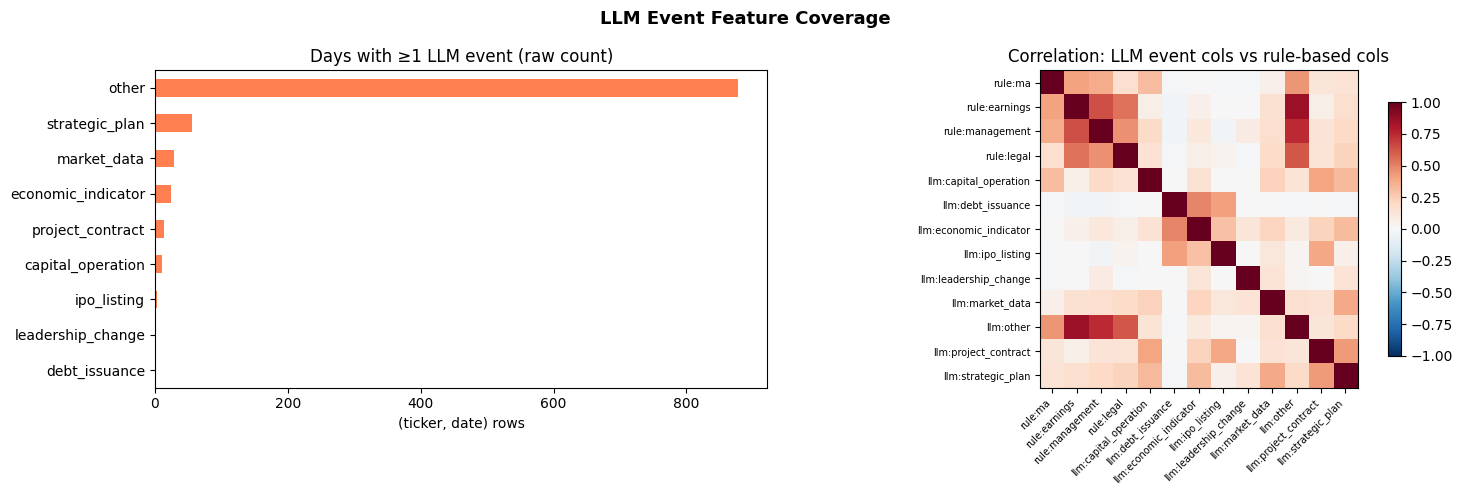

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("LLM Event Feature Coverage", fontsize=13, fontweight="bold")

# Days with ≥1 LLM event signal (per event type)
llm_base = [c for c in LLM_EVT_COLS if "_r" not in c]
coverage = (features[llm_base] > 0).sum().rename(
    index=lambda x: x.replace("llm_evt_", "")
).sort_values()
coverage.plot.barh(ax=axes[0], color="coral")
axes[0].set_title("Days with ≥1 LLM event (raw count)")
axes[0].set_xlabel("(ticker, date) rows")

# Feature correlation heatmap: LLM event cols vs rule-based event cols
import numpy as np
corr_cols = [c for c in features.columns
             if (c.startswith("llm_evt_") or c.startswith("event_")) and "_r" not in c]
corr = features[corr_cols].corr()
im = axes[1].imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr_cols)))
axes[1].set_xticklabels(
    [c.replace("llm_evt_", "llm:").replace("event_", "rule:") for c in corr_cols],
    rotation=45, ha="right", fontsize=7
)
axes[1].set_yticks(range(len(corr_cols)))
axes[1].set_yticklabels(
    [c.replace("llm_evt_", "llm:").replace("event_", "rule:") for c in corr_cols],
    fontsize=7
)
axes[1].set_title("Correlation: LLM event cols vs rule-based cols")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## 6 · Quick visual check — sentiment signal

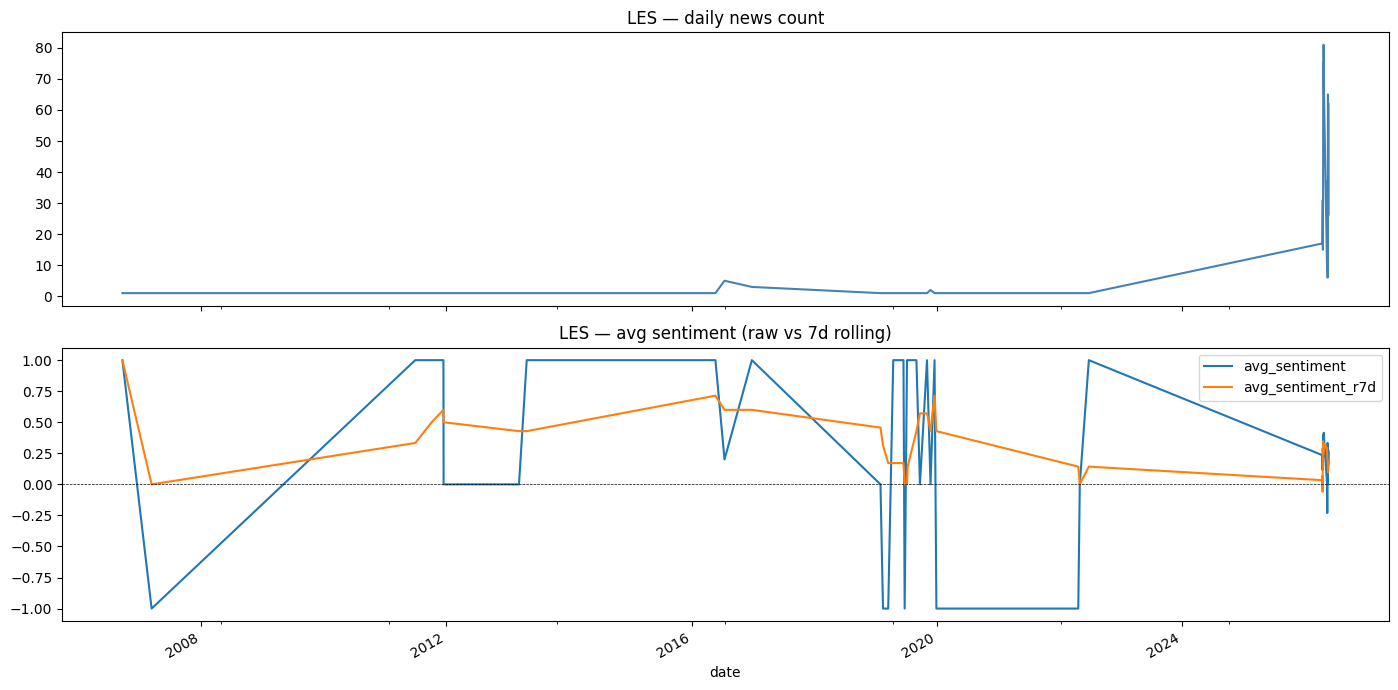

In [9]:
# Pick the ticker with the most news coverage for the plot
top_ticker = features.groupby("ticker")["news_count"].sum().idxmax()
ticker_df  = features[features["ticker"] == top_ticker].set_index("date")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ticker_df["news_count"].plot(ax=axes[0], color="steelblue")
axes[0].set_title(f"{top_ticker} — daily news count")

ticker_df[["avg_sentiment", "avg_sentiment_r7d"]].plot(ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title(f"{top_ticker} — avg sentiment (raw vs 7d rolling)")

plt.tight_layout()
plt.show()

## 7 · Save

In [10]:
save(features, "features")

  saved 892 rows  →  features.parquet


WindowsPath('C:/_PROJECTS/pfa_bvc/Notebooks/signal_pipeline/data/features.parquet')